# Simple Linear Regression - Data Exploration

## Objective

This notebook explores the Advertising dataset before building a Simple Linear Regression model.

For the first stage of the project, we investigate the relationship between:

- Feature: TV advertising expenditure
- Target: Sales

The objective is to determine whether a linear relationship appears reasonable before implementing the regression algorithm.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [6]:
column_names = ["Id", "TV", "Radio", "Newspaper", "Sales"]
df.columns = column_names
df.columns

Index(['Id', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [8]:
df.head()

,Id,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [9]:
df.shape

(200, 5)

In [10]:
df = df.drop(columns=["Id"])
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [11]:
df.shape

(200, 4)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [13]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [15]:
# Percentage of missing values
df.isnull().mean() * 100

TV           0.0
Radio        0.0
Newspaper    0.0
Sales        0.0
dtype: float64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [21]:
# We are doing Simple Linear Regression so we are only choosing one feature here that is TV
X = df["TV"]
y = df["Sales"]

In [22]:
X.describe()

count    200.000000
mean     147.042500
std       85.854236
min        0.700000
25%       74.375000
50%      149.750000
75%      218.825000
max      296.400000
Name: TV, dtype: float64

In [23]:
y.describe()

count    200.000000
mean      14.022500
std        5.217457
min        1.600000
25%       10.375000
50%       12.900000
75%       17.400000
max       27.000000
Name: Sales, dtype: float64

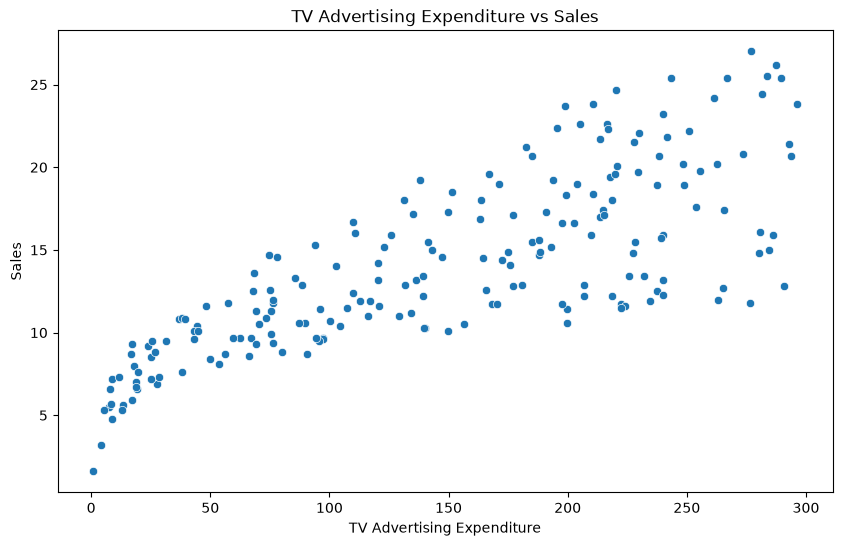

In [25]:
# This tells does increasing on TV advertisement increases the Sales or not
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("TV Advertising Expenditure vs Sales")
plt.xlabel("TV Advertising Expenditure")
plt.ylabel("Sales")

plt.show()

In [28]:
# The correlation tells that the expenditure on TV increase the sales
df["TV"].corr(df["Sales"])

np.float64(0.7822244248616066)

In [29]:
df[["TV", "Sales"]].corr()

,TV,Sales
TV,1.000000,0.782224
Sales,0.782224,1.000000


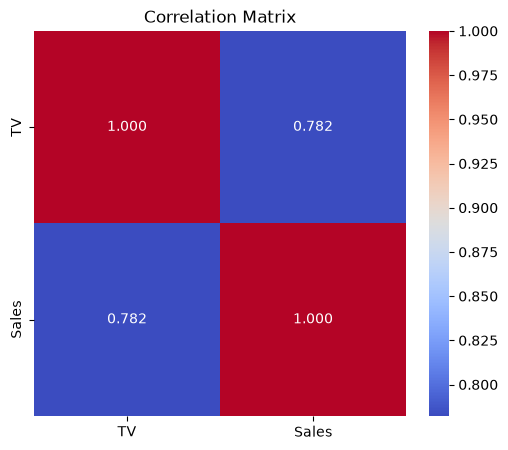

In [30]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    df[["TV", "Sales"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".3f"
)

plt.title("Correlation Matrix")

plt.show()

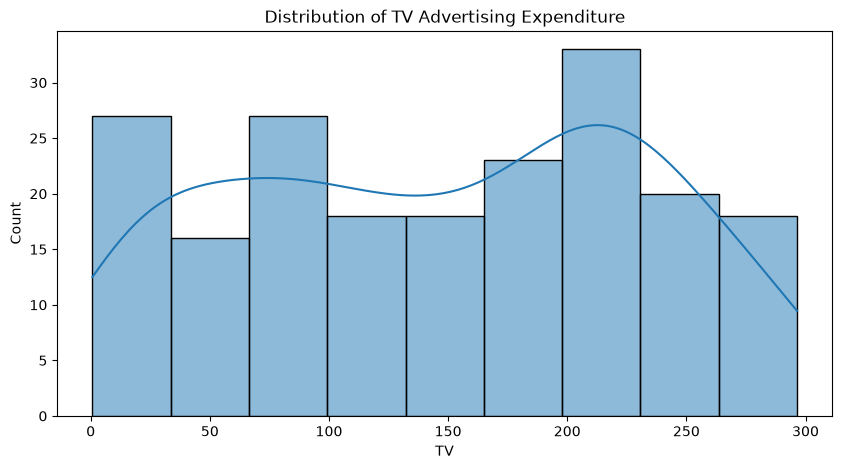

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="TV",
    kde=True
)

plt.title("Distribution of TV Advertising Expenditure")

plt.show()

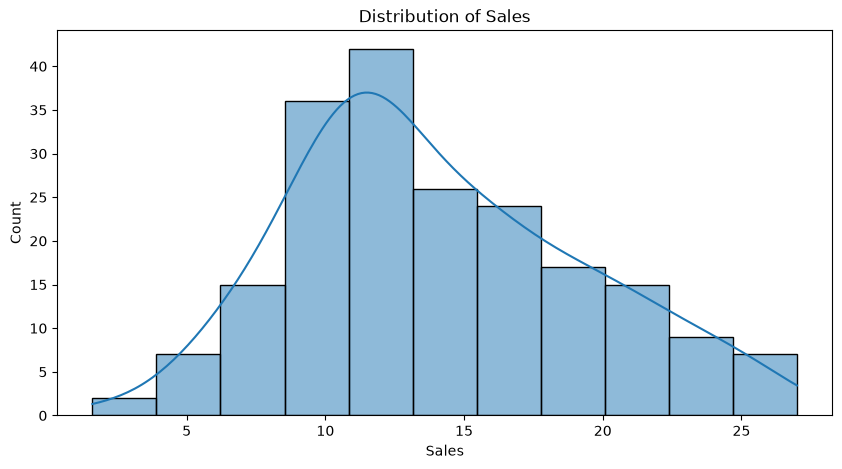

In [32]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Sales",
    kde=True
)

plt.title("Distribution of Sales")

plt.show()

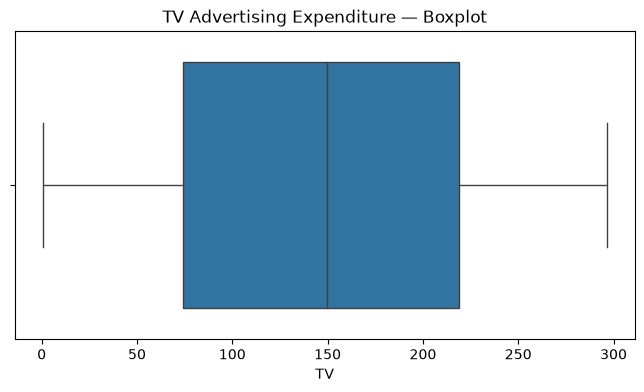

In [33]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["TV"])

plt.title("TV Advertising Expenditure — Boxplot")

plt.show()

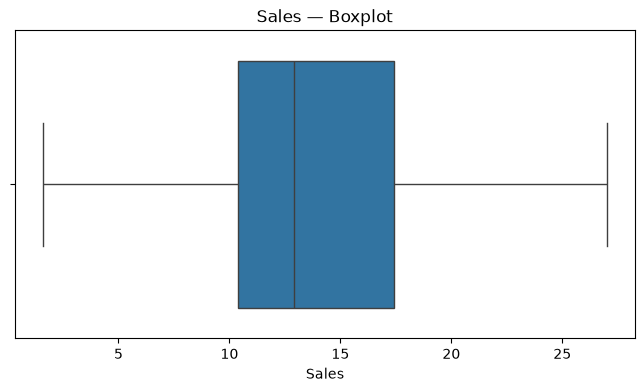

In [34]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Sales"])

plt.title("Sales — Boxplot")

plt.show()

## Initial Findings

1. The dataset contains 200 observations and four numerical variables.
2. TV advertising expenditure and Sales are both numerical variables.
3. The TV-Sales scatter plot suggests an approximately positive linear relationship.
4. Correlation provides an initial quantitative measure of association.
5. Distribution and boxplot analysis provides information about the spread and potential extreme observations.
6. These observations motivate the use of Simple Linear Regression for the initial experiment.

These observations do not establish causality. The purpose of this analysis is to assess whether a linear model is a reasonable starting point for the dataset.